#### Решение двумерного нестационарного уравнения Навье-Стокса для ламинарного течения несжимаемой жидкости в канале (течение Пуазёйля)

По мотивам статьи (Rao) Physics-informed deep learning for incompressible laminar flows

**Уравнение Навье-Стокса для несжимаемой жидкости, дополненое уравнением неразрывности:**

$
\begin{cases}
    \dfrac{\partial \vec{v}}{\partial t} + \left( \vec{v} \cdot \nabla \right) \vec{v} = \dfrac{1}{\rho} \nabla \cdot \sigma + \vec{f},  \\
    \nabla \cdot \vec{v} = 0,
\end{cases}
$

где 
- $\vec{v} = (u, \mathrm{v})^T$ — векторное поле скоростей,
- $\rho = \mathrm{const}$ — плотность жидкости,
- $\sigma = -p I + \mu \left[ \nabla \vec{v} + (\nabla \vec{v})^T \right]$ — тензор напряжений Коши, $\left[ \sigma_{ij} \right] = M / (L \cdot T^2)$,
- $\mu$ — коэффициент динамической вязкости, $\left[ \mu \right]$ = $M / (L \cdot T)$,
- $\vec{f}$ — сила на единицу массы, $\left[ f \right]$ = $L / T^2$.

<br>

**Обезразмеривание:**

- $\widetilde{L}$ — характерная длина,
- $\widetilde{U}$ — характерная скорость,
- $\widetilde{T} = \widetilde{L} / \widetilde{U}$ — характерное время,
- $\widetilde{\Sigma} = \rho \widetilde{U}^2$
- $\widetilde{F} = \widetilde{U}^2 / \widetilde{L}$ — характерная сила на единицу массы,
- $\widetilde{P} = \rho \widetilde{U}^2$ — характерное давление,
- $\mathrm{Re} = \rho \widetilde{U} \widetilde{L} / \mu $ — число Рейнольдса


Обезразмеренное уравнение Навье-Стокса для несжимаемой жидкости, дополненое уравнением неразрывности:

$
\begin{cases}
    \dfrac{\partial \vec{\widetilde{v}}}{\partial \tilde{t}} + \left( \vec{\widetilde{v}} \cdot \nabla \right) \vec{\widetilde{v}} = \nabla \cdot \widetilde{\sigma} + \vec{\widetilde{f}},  \\
    \nabla \cdot \vec{\widetilde{v}} = 0,
\end{cases}
$

где $\widetilde{\sigma} = -\widetilde{p} I + \dfrac{1}{\mathrm{Re}} \left[ \nabla \vec{\widetilde{v}} + (\nabla \vec{\widetilde{v}})^T \right]$

<br>

**Постановка задачи:**

![alt text](pictures/navier-stokes_2d_incompressible_nonsteady_obstacle.png)

$
\begin{cases}
    \dfrac{\partial \vec{v}}{\partial t} + \left( \vec{v} \cdot \nabla \right) \vec{v} - \dfrac{1}{\rho} \nabla \cdot \sigma = 0,  \\
    \nabla \cdot \vec{v} = 0,
\end{cases}
$

Начальное и краевые условия: 
- $\left. \vec{v} \right|_{t=t_{\mathrm{min}}} = \left. p \right|_{t=t_{\mathrm{min}}} = 0$ — начальное условие,
- $\left. \vec{v} \right|_{\Gamma_1} = \left. \vec{v} \right|_{\Gamma_2} = \left. \vec{v} \right|_{\Gamma_5} = 0$ — условия прилипания,
- $\left. u \right|_{\Gamma_3} = - \dfrac{U_\mathrm{max}}{h^2} (y - y_\mathrm{min}) (y - y_\mathrm{max}) \cdot \mathrm{step(t - 0{,}05 \; с)}$ — профиль течения Пуазейля,
- $\left. p \right|_{\Gamma_4} = 0$.

Здесь:
- $U_\mathrm{max}$ — задаваемый параметр;
- $h = (y_\mathrm{max} - y_\mathrm{min}) / 2$; 
- $
  \mathrm{step}(t) =
  \begin{cases}
  0, & t < d, \\
  0.5 + \dfrac{15}{16}\dfrac{t}{d} - \dfrac{5}{8}\left(\dfrac{t}{d}\right)^3 + \dfrac{3}{16}\left(\dfrac{t}{d}\right)^5, & -d \le t \le d, \\
  1, & t > d;
  \end{cases}
  $ 
  
  где $d = 0{,}05$ — половина ширины переходной зоны;
- $\Gamma_1$, $\Gamma_2$ — боковые стенки трубы;
- $\Gamma_3$, $\Gamma_4$ — вход в трубу и выход из неё соответственно;
- $\Gamma_5$ — препятствие диаметром $d_\mathrm{obs} = 0{,}5 h$ с координатами центра $(x_\mathrm{obs}, y_\mathrm{obs}) = (x_\mathrm{min}, y_\mathrm{min}) + (1{,}25 h, h)$.

Задача решается относительно скалярной функции тока $\psi(x,y)$, такой что $u = \partial_y \psi$, $v = -\partial_x \psi$

In [1]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/Colab Notebooks/NN_pytorch_BVP
%ls -l

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks/NN_pytorch_BVP
total 24
drwx------ 2 root root 4096 Feb 14 14:35 data/
drwx------ 2 root root 4096 Mar 27 21:45 NN_pytorch_BVP/
drwx------ 2 root root 4096 Feb 14 14:35 notebooks/
drwx------ 2 root root 4096 Feb 14 14:38 runs/
drwx------ 2 root root 4096 Feb 14 14:35 scripts/
drwx------ 2 root root 4096 Feb 14 14:35 tests/


In [ ]:
import time
from pathlib import Path
from datetime import datetime
from dataclasses import dataclass, replace, asdict, field, fields
import math
from contextlib import nullcontext
import json

import torch
import torch.optim as optim
import torch.nn as nn
from scipy.interpolate import NearestNDInterpolator
import matplotlib.pyplot as plt
import matplotlib.animation as anim
import matplotlib.ticker as mticker
import matplotlib.colors as colors
import matplotlib.tri as tri
import matplotlib as mpl
import numpy as np
from tqdm import trange

from NN_pytorch_BVP.pinn import MultilayerPerceptronWithFFE, compute_grad_theta_norm, sample_points_3D

mpl.rcParams.update({
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.linewidth": 0.5,
    "grid.alpha": 1.0,   # optional
})
            
# Для аккуратного масштабирования пределов оси Y во время рендера анимации обучения
def smooth_autoscale_y_hysteresis(ax, y, pad=0.05, alpha_shrink=0.08):
    """
    Smoothly adjust the y-axis limits to follow streaming data.

    Each call computes target y-limits from the current data `y` (with a small
    padding), then updates the axes limits with hysteresis:
      - expand immediately if the new data exceeds the current limits (avoid clipping)
      - shrink gradually toward tighter limits (reduce jitter/"breathing")

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axes whose y-limits will be updated.
    y : array-like
        Current y-data (list/NumPy array/torch tensor converted to array).
    pad : float, default=0.05
        Fractional padding added above and below the data range.
    alpha_shrink : float, default=0.08
        Smoothing factor for shrinking (0 < alpha <= 1). Smaller = smoother/slower.
    """
    y = np.asarray(y)
    ymin, ymax = np.nanmin(y), np.nanmax(y)
    if ymin == ymax:
        ymin -= 1.0
        ymax += 1.0

    yr = ymax - ymin
    ymin_t = ymin - pad * yr
    ymax_t = ymax + pad * yr

    cur_ymin, cur_ymax = ax.get_ylim()

    # Expand immediately if needed
    if ymin_t < cur_ymin:
        cur_ymin = ymin_t
    else:  # shrink slowly
        cur_ymin = (1 - alpha_shrink) * cur_ymin + alpha_shrink * ymin_t

    if ymax_t > cur_ymax:
        cur_ymax = ymax_t
    else:
        cur_ymax = (1 - alpha_shrink) * cur_ymax + alpha_shrink * ymax_t

    ax.set_ylim(cur_ymin, cur_ymax)

# Вычисление градиента тензора при помощи torch.autograd. Пример: dy_dx = compute_grad(y, x)
def compute_grad(y, x, create_graph=True, retain_graph=None):
    if retain_graph is None:
        retain_graph = create_graph
    return torch.autograd.grad(
        y, x, grad_outputs=torch.ones_like(y), 
        create_graph=create_graph, retain_graph=retain_graph)[0]

# Вычисляет проекции скоростей u и v из потоковой функции psi, т.к. u = dpsi/dy, v = -dpsi/dx
def get_uv_from_psi(txy, psi, create_graph=True):
    _, v, u = torch.split(compute_grad(psi, txy, create_graph=create_graph), 1, dim=1) 
    return u, -v

def step_smoothed(
    x: torch.Tensor, x0: float = 0.0, 
    transition_zone_size: float = 0.1, min_value: float = 0.0, max_value: float = 1.0
) -> torch.Tensor:
    """
    Compute a smooth approximation of a step function.

    The function transitions from ``min_value`` to ``max_value`` around ``x0``.
    Outside the transition zone, the output is constant. Inside the transition
    zone, a quintic polynomial is used to ensure a smooth interpolation.

    Parameters
    ----------
    x : torch.Tensor
        Input tensor.
    x0 : float, default=0.0
        Center of the transition.
    transition_zone_size : float, default=0.1
        Width of the transition zone centered at ``x0``. The function equals
        ``min_value`` for ``x <= x0 - transition_zone_size / 2`` and
        ``max_value`` for ``x >= x0 + transition_zone_size / 2``.
    min_value : float, default=0.0
        Output value below the transition zone.
    max_value : float, default=1.0
        Output value above the transition zone.

    Returns
    -------
    torch.Tensor
        Tensor of the same shape as ``x``, containing the smoothed step values.

    Notes
    -----
    The interpolation inside the transition zone is given by a fifth-degree
    polynomial, which provides a smooth transition with continuous derivatives.

    """
    d = transition_zone_size / 2.0
    xi = x - x0

    t = xi / d
    middle = 0.5 + (15.0/16.0)*t - (5.0/8.0)*t**3 + (3.0/16.0)*t**5

    h = torch.where(
        xi <= -d, 
        torch.zeros_like(xi),
        torch.where(xi >= d, torch.ones_like(xi), middle)
    )

    return min_value + (max_value - min_value) * h

def get_trainable_layers(model):
    """
    Collect submodules that directly own a trainable weight tensor.

    This function traverses ``model`` recursively using ``model.named_modules()``
    and returns all non-root submodules that have a non-``None`` ``weight``
    attribute. The traversal order is preserved, so the returned lists can be
    used to define a stable layer ordering for logging and plotting.

    Parameters
    ----------
    model : torch.nn.Module
        PyTorch model whose submodules are to be inspected.

    Returns
    -------
    tuple[list[torch.nn.Module], list[str]]
        A pair ``(layers, names)`` where

        - ``layers`` is the list of submodules with a non-``None`` weight tensor.
        - ``names`` is the list of corresponding module names from
          ``model.named_modules()``.

        Both lists have the same length, and ``names[i]`` is the name of
        ``layers[i]``.

    Notes
    -----
    This function selects modules by checking for a ``weight`` attribute, so it
    typically includes layers such as ``nn.Linear`` and other weighted modules,
    while skipping activation layers and container modules that do not directly
    store parameters.
    """
    layers = []
    names = []

    for name, module in model.named_modules():
        if name == "":
            continue
        
        if hasattr(module, "weight") and module.weight is not None:
            layers.append(module)
            names.append(name)

    return layers, names

def mean_square(x: torch.Tensor) -> float:
    return torch.mean(x.detach() ** 2).item()

def log_per_layer_ms(    # ms = mean square
    log_idx: int, 
    logged_layers: list, 
    weight_ms_history: torch.Tensor,
    bias_ms_history: torch.Tensor, 
    weight_grad_ms_history: torch.Tensor, 
    bias_grad_ms_history: torch.Tensor
) -> None:
    """
    Log per-layer parameter and gradient mean squares into preallocated tensors.

    For each layer in ``logged_layers``, this function stores the mean square of
    the layer weight tensor, bias tensor, weight gradient, and bias gradient at
    row ``log_idx`` of the corresponding history tensors. If a layer has no bias,
    or if a gradient is unavailable, ``NaN`` is written to the appropriate entry.

    Parameters
    ----------
    log_idx : int
        Row index in the history tensors corresponding to the current logging step.
    logged_layers : list[torch.nn.Module]
        Ordered list of layers to monitor. Each layer is expected to have a
        ``weight`` attribute, and may optionally have a ``bias`` attribute.
    weight_ms_history : torch.Tensor
        Tensor of shape ``(n_log, n_layers)`` storing per-layer weight mean
        squares over training.
    bias_ms_history : torch.Tensor
        Tensor of shape ``(n_log, n_layers)`` storing per-layer bias mean
        squares over training.
    weight_grad_ms_history : torch.Tensor
        Tensor of shape ``(n_log, n_layers)`` storing per-layer weight-gradient
        mean squares over training.
    bias_grad_ms_history : torch.Tensor
        Tensor of shape ``(n_log, n_layers)`` storing per-layer bias-gradient
        mean squares over training.

    Returns
    -------
    None
        The input history tensors are modified in place.

    Notes
    -----
    This function should be called after ``loss.backward()`` so that parameter
    gradients are available, and before gradients are cleared by
    ``optimizer.zero_grad()``. The ordering of ``logged_layers`` defines the
    column ordering in all history tensors.
    """
    for j, layer in enumerate(logged_layers):
        # parameter mean squares
        weight_ms_history[log_idx, j] = mean_square(layer.weight)
        if hasattr(layer, "bias") and layer.bias is not None:
            bias_ms_history[log_idx, j] = mean_square(layer.bias)
        else:
            bias_ms_history[log_idx, j] = float("nan")

        # gradient mean squares
        if layer.weight.grad is not None:
            weight_grad_ms_history[log_idx, j] = mean_square(layer.weight.grad)
        else: 
            weight_grad_ms_history[log_idx, j] = float("nan")
        if hasattr(layer, "bias") and layer.bias is not None and layer.bias.grad is not None:
            bias_grad_ms_history[log_idx, j] = mean_square(layer.bias.grad)
        else:
            bias_grad_ms_history[log_idx, j] = float("nan")

torch.manual_seed(2008)
 
@dataclass(frozen=True)
class PINNConfig:
    # Problem parameters
    xlims: list[float] = field(default_factory=lambda: [-3.0, -1.0])    # x_min, x_max (метры)
    ylims: list[float] = field(default_factory=lambda: [-0.1, 0.4])    # y_min, y_max (метры)
    tlims: list[float] = field(default_factory=lambda: [0.0, 0.35])    # t_min, t_max
    coords_obs: list[float] = field(init=False)    # x_obs, y_obs
    d_obs: float = field(init=False)
    nu: float = 0.00103    # кинематическая вязкость (масло касторовое), м2/с
    rho: float = 960    # плотность (масло касторовое), кг/м3
    u0: float = 1.0    # начальная скорость в центре потока, м/с

    # Для обезразмеривания
    L_wave: float = field(init=False)    # характерная длина, м
    U_wave: float = field(init=False)    # характерная скорость, м/с
    T_wave: float = field(init=False)    # характерное время, с
    P_wave: float = field(init=False)    # характерное давление, Па
    F_wave: float = field(init=False)    # характерная сила на единицу массы, Н/кг
    Re: float = field(init=False)    # число Рейнольдса
    Sigma_wave: float = field(init=False)    # характерное механическое напряжение, Н/м2

    # Model parameters
    device: torch.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    init_scheme: str = "glorot_normal"
    layers: list[int] = field(default_factory=lambda: [3, 256, 256, 5])   # (t, x, y) -> (psi, p, sigma_xx, sigma_xy(=sigma_yx), sigma_yy)

    # Training parameters
    results_folder: Path = Path.cwd() / 'runs' / "navier-stokes_2d_incompressible_nonsteady_obstacle"
    n_epochs: int = 5000
    n_r: int = 80000
    n_ic: int = field(init=False)
    n_bc_x: int = field(init=False)
    n_bc_y: int = field(init=False)
    n_bc_obs: int = field(init=False)
    n_batches: int = 10    # number of batches per epoch
    batch_size_r: int = field(init=False)
    batch_size_ic: int = field(init=False)
    batch_size_bc_x: int = field(init=False)
    batch_size_bc_y: int = field(init=False)
    batch_size_bc_obs: int = field(init=False)
    lambda_r: float = 1.0
    lambda_ic: float = 1.0
    lambda_walls: float = 1.0
    lambda_inlet: float = 1.0
    lambda_outlet: float = 1.0
    lr: float = 1e-3    # initial learning rate
    use_static_training_set: bool = False
    logging_freq: int = 1    # log metrics once every N gradient descent steps

    # Log metrics (like loss and error) during training for different t intervals
    use_temporal_logging: bool = True
    temporal_logging_freq: int = 200    # log metrics once every N gradient descent steps
    temporal_logging_nbins: int = 10    # Slice time into this number of equal segments

    # Checkpointing
    use_checkpointing: bool = False
    checkpointing_freq: int = 2000    # save model and metrics to the results_folder once every N gradient descent steps

    # Fourier Feature embedding
    use_FFE: bool = False
    FFE_m: int = 100
    FFE_sigma: float = 1.0
    FFE_keep_dims: None | list[int] = None    # Indices of input dimensions to be passed through unchanged

    # Grad norm weighting
    use_grad_norm_weighting: bool = False
    grad_norm_weighting_alpha: float = 0.9
    grad_norm_weighting_freq: int = 200    # update lambdas once every N gradient descent steps

    # Causal weighting
    use_causal_weighting_scheme: bool = False
    causal_m: int = 10
    causal_eps: float = 100.0
    W_logging_freq: int = 100    # log temporal weights and L_t once every N gradient descent steps

    # Video parameters
    render_video: bool = False
    video_fps: int = 30
    video_dpi: int = 100
    video_render_freq: int = 100    # render a frame once every N gradient descent steps

    def __str__(self):
        res = []
        for field in fields(self):
            res.append(f"{field.name}: {getattr(self, field.name)}")
        return "\n".join(res)
    
    def __post_init__(self):
        xlims = self.xlims[:]
        ylims = self.ylims[:]
        tlims = self.tlims[:]

        h = (ylims[1] - ylims[0])/2
        coords_obs = [xlims[0] + 1.25*h, ylims[0] + h]
        d_obs = 0.5*h
        object.__setattr__(self, "coords_obs", coords_obs)
        object.__setattr__(self, "d_obs", d_obs)

        Lx = xlims[1] - xlims[0]
        Ly = ylims[1] - ylims[0]
        T = tlims[1] - tlims[0]
        tmp = (self.n_r/(Lx*Ly*T))**(2.0/3.0)
        n_ic = math.ceil( Lx*Ly*tmp )
        n_bc_x = max(
            2, 
            2 * math.ceil( Ly*T*tmp )
        )
        n_bc_y = max(
            2, 
            2 * math.ceil( Lx*T*tmp )
        )
        n_bc_obs = 5 * max(1, math.ceil(math.pi*d_obs*T*tmp))

        object.__setattr__(self, "n_ic", n_ic)
        object.__setattr__(self, "n_bc_x", n_bc_x)
        object.__setattr__(self, "n_bc_y", n_bc_y)
        object.__setattr__(self, "n_bc_obs", n_bc_obs)

        batch_size_r = self.n_r / self.n_batches
        batch_size_ic = n_ic / self.n_batches
        if batch_size_ic < 1:
           raise ValueError(f"batch_size_ic turned out to be less than 1 ({batch_size_ic:.1f})." + 
               " Increase n_r or decrease n_batches!")
        batch_size_bc_x = n_bc_x / self.n_batches
        if batch_size_bc_x < 2:
            raise ValueError(f"batch_size_bc_x turned out to be less than 2 ({batch_size_bc_x:.1f})." +
                " Increase n_r or decrease n_batches!")
        batch_size_bc_y = n_bc_y / self.n_batches
        if batch_size_bc_y < 2:
            raise ValueError(f"batch_size_bc_y turned out to be less than 2 ({batch_size_bc_y:.1f})." +
                " Increase n_r or decrease n_batches!")
        batch_size_bc_obs = n_bc_obs / self.n_batches
        if batch_size_bc_obs < 1:
            raise ValueError(f"batch_size_bc_obs turned out to be less than 1 ({batch_size_bc_obs:.1f})." +
                " Increase n_r or decrease n_batches!")
        object.__setattr__(self, "batch_size_r", math.ceil(batch_size_r))
        object.__setattr__(self, "batch_size_ic", math.ceil(batch_size_ic))
        object.__setattr__(self, "batch_size_bc_x", math.ceil(batch_size_bc_x))
        object.__setattr__(self, "batch_size_bc_y", math.ceil(batch_size_bc_y))
        object.__setattr__(self, "batch_size_bc_obs", math.ceil(batch_size_bc_obs))

        # Обезразмеривание
        object.__setattr__(self, "L_wave", Ly / 2.0)
        object.__setattr__(self, "U_wave", self.u0)
        object.__setattr__(self, "T_wave", self.L_wave / self.U_wave)
        object.__setattr__(self, "P_wave", self.rho * self.U_wave**2)
        object.__setattr__(self, "F_wave", self.U_wave / self.T_wave)
        object.__setattr__(self, "Re", self.U_wave * self.L_wave / self.nu)
        object.__setattr__(self, "Sigma_wave", self.rho * self.U_wave**2)

class Trainer:
    def __init__(self, model, optimizer, scheduler, cfg: PINNConfig):
        self.model = model.to(cfg.device)
        self.optimizer = optimizer
        self.scheduler = scheduler
        self.cfg = cfg
        self.results_folder = self.cfg.results_folder
        self.results_folder.mkdir(parents=True, exist_ok=True)

        if cfg.use_checkpointing:
            (self.results_folder / "model").mkdir(parents=True, exist_ok=True)
            (self.results_folder / "metrics").mkdir(parents=True, exist_ok=True)

        # Save cfg dataclass object to the results folder as json
        def to_jsonable(x):
            if isinstance(x, Path):
                return str(x)
            if isinstance(x, torch.device):
                return str(x)
            return x
        data = {k: to_jsonable(v) for k, v in asdict(cfg).items()}
        del data["results_folder"]
        (self.results_folder / "config.json").write_text(json.dumps(data, indent=2))

        self.xlims = [cfg.xlims[0]/cfg.L_wave, cfg.xlims[1]/cfg.L_wave]
        self.ylims = [cfg.ylims[0]/cfg.L_wave, cfg.ylims[1]/cfg.L_wave]
        self.tlims = [cfg.tlims[0]/cfg.T_wave, cfg.tlims[1]/cfg.T_wave]
        self.coords_obs = [cfg.coords_obs[0]/cfg.L_wave, cfg.coords_obs[1]/cfg.L_wave]
        self.d_obs = cfg.d_obs/self.cfg.L_wave
        self.u0 = cfg.u0/cfg.U_wave
        self.h = (cfg.ylims[1] - cfg.ylims[0]) / 2.0 / cfg.L_wave
        self.nu = cfg.nu
        self.rho = cfg.rho
        self.device = cfg.device
        self.use_static_training_set = cfg.use_static_training_set

        # Log metrics (like loss and error) during training for different t intervals
        self.use_temporal_logging = cfg.use_temporal_logging
        self.temporal_logging_freq = cfg.temporal_logging_freq
        self.temporal_logging_nbins = cfg.temporal_logging_nbins
        self.temporal_logging_edges = torch.linspace(
            self.tlims[0], self.tlims[1], self.temporal_logging_nbins + 1, device=self.device
        )
        
        # Идеология работы с безразмерными величинами следующая: каждый метод класса Train
        # работает в безразмерных единицах. Все величины, которые подразумевают обезразмеривание,
        # обезразмериваются. В конфиге cfg всё остаётся размерным
        self.L_wave = cfg.L_wave
        self.U_wave = cfg.U_wave
        self.T_wave = cfg.T_wave
        self.P_wave = cfg.P_wave
        self.Re_inv = 1.0 / cfg.Re

        self.grad_norm_weighting_alpha = cfg.grad_norm_weighting_alpha
        self.use_causal_weighting_scheme = cfg.use_causal_weighting_scheme
        self.causal_m = cfg.causal_m
        self.causal_eps = cfg.causal_eps

        data = torch.load(Path.cwd() / "data" / "navier-stokes_2d_incompressible_nonsteady_obstacle.pt", map_location=self.device)
        txy = data['txy']; uvp = data['uvp']
        txy[:, 1:3] = txy[:, 1:3] / self.L_wave    # x, y
        txy[:, 0] = txy[:, 0] / self.T_wave    # t
        uvp[:, 0:2] = uvp[:, 0:2] / self.U_wave    # u, v
        uvp[:, 2] = uvp[:, 2] / self.P_wave    # p
        txy = txy.to(self.device)
        uvp = uvp.to(self.device)
        #txy = torch.tensor(txy], dtype=torch.float32, device=self.device)
        #uvp = torch.tensor(uvp], dtype=torch.float32, device=self.device)
        self.interpolator = NearestNDInterpolator(txy.detach().cpu(), uvp.detach().cpu())

        self.causal_edges = torch.linspace(
            self.tlims[0], self.tlims[1], self.causal_m + 1, device=self.device
        )

        self.logged_layers, self.logged_layer_names = get_trainable_layers(model)

    def uvp_exact(self, txy):
        uvp = torch.tensor(self.interpolator(txy.detach().cpu()), dtype=txy.dtype, device=txy.device)
        return uvp

    def sample_rectangle_minus_circle(self, n: int, oversample_factor: float = 1.2) -> torch.Tensor:
        x_min, x_max = self.xlims
        y_min, y_max = self.ylims
        t_min, t_max = self.tlims
        cx, cy = self.coords_obs
        r = self.d_obs / 2.0

        A_r = (x_max - x_min) * (y_max - y_min)
        A_c = torch.pi * r * r
        
        txy_total = []
        n_total = 0
        while n_total < n:
            N = math.ceil( oversample_factor * (n - n_total) * A_r / (A_r - A_c) )
            txy = sample_points_3D(
                [t_min, x_min, y_min, t_max, x_max, y_max], N, scheme="uniform", device=self.device
            )
            mask = (txy[:, 1] - cx)**2 + (txy[:, 2] - cy)**2 > r**2 
            txy_total.append(txy[mask])
            n_total += len(txy_total[-1])

        return torch.cat(txy_total)[:n, :]

    def sample_points(self, n_r: int, n_ic: int, n_bc_x: int, n_bc_y: int, n_bc_obs: int):
        x_min, x_max = self.xlims
        y_min, y_max = self.ylims
        t_min, t_max = self.tlims
        x_obs, y_obs = self.coords_obs
        d_obs = self.d_obs

        # Domain
        txy_r = self.sample_rectangle_minus_circle(n_r)
        txy_r.requires_grad_(True)

        # Initial conditions
        txy_ic = self.sample_rectangle_minus_circle(n_ic)
        txy_ic[:, 0] = t_min
        txy_ic.requires_grad_(True)

        # Boundary conditions for rectangle boundaries
        txy_bc_xmin = sample_points_3D(
            [t_min, x_min, y_min, t_max, x_min, y_max], 
            n_bc_x // 2, scheme="uniform", device=self.device
        )
        txy_bc_xmin.requires_grad_(True)
        txy_bc_xmax = sample_points_3D(
            [t_min, x_max, y_min, t_max, x_max, y_max], 
            n_bc_x // 2, scheme="uniform", device=self.device
        )
        txy_bc_xmax.requires_grad_(True)
        txy_bc_ymin = sample_points_3D(
            [t_min, x_min, y_min, t_max, x_max, y_min], 
            n_bc_y // 2, scheme="uniform", device=self.device
        )
        txy_bc_ymin.requires_grad_(True)
        txy_bc_ymax = sample_points_3D(
            [t_min, x_min, y_max, t_max, x_max, y_max], 
            n_bc_y // 2, scheme="uniform", device=self.device
        )
        txy_bc_ymax.requires_grad_(True)

        # Boundary conditions for obstacle
        tmp = sample_points_3D(
            [t_min, d_obs/2.0, 0.0, t_max, d_obs/2.0, 2.0*torch.pi],
            n_bc_obs, scheme="uniform", device=self.device
        )
        txy_bc_obs = torch.zeros_like(tmp)
        txy_bc_obs[:, 0] = tmp[:, 0]
        txy_bc_obs[:, 1] = x_obs + tmp[:, 1] * torch.cos(tmp[:, 2])
        txy_bc_obs[:, 2] = y_obs + tmp[:, 1] * torch.sin(tmp[:, 2])
        txy_bc_obs.requires_grad_(True)

        return txy_r, txy_ic, txy_bc_xmin, txy_bc_xmax, txy_bc_ymin, txy_bc_ymax, txy_bc_obs

    def compute_res_r(self, txy):
        out = self.model(txy)

        psi, p, sigma_xx, sigma_xy, sigma_yy = torch.split(out, 1, dim=1)
        u, v = get_uv_from_psi(txy, psi)
        du_dt, du_dx, du_dy = torch.split(compute_grad(u, txy), 1, dim=1)
        dv_dt, dv_dx, dv_dy = torch.split(compute_grad(v, txy), 1, dim=1)

        d_sigma_xx_dx = compute_grad(sigma_xx, txy)[:, 1:2]
        d_sigma_yy_dy = compute_grad(sigma_yy, txy)[:, 2:3]
        _, d_sigma_yx_dx, d_sigma_xy_dy = torch.split(compute_grad(sigma_xy, txy), 1, dim=1)

        Re_inv = self.Re_inv
        res_x = du_dt + u*du_dx + v*du_dy - d_sigma_xx_dx - d_sigma_xy_dy
        res_y = dv_dt + u*dv_dx + v*dv_dy - d_sigma_yx_dx - d_sigma_yy_dy
        res_sigma_xx = sigma_xx + p - 2.0*Re_inv*du_dx
        res_sigma_xy = sigma_xy - Re_inv*( du_dy + dv_dx )
        res_sigma_yy = sigma_yy + p - 2.0*Re_inv*dv_dy
        res_p = p + (sigma_xx + sigma_yy) / 2.0

        return res_x, res_y, res_sigma_xx, res_sigma_xy, res_sigma_yy, res_p

    def compute_res_ic(self, txy):
        out = self.model(txy)
        psi = out[:, 0:1]
        u, v = get_uv_from_psi(txy, psi)

        res_u = u
        res_v = v
        res_p = out[:, 1:2]

        return res_u, res_v, res_p
    
    def compute_res_walls(self, txy_ymin, txy_ymax, txy_obs):
        out_ymin = self.model(txy_ymin)
        u_ymin, v_ymin = get_uv_from_psi(txy_ymin, out_ymin[:, 0:1])

        out_ymax = self.model(txy_ymax)
        u_ymax, v_ymax = get_uv_from_psi(txy_ymax, out_ymax[:, 0:1])

        out_obs = self.model(txy_obs)
        u_obs, v_obs = get_uv_from_psi(txy_obs, out_obs[:, 0:1])

        return u_ymin, v_ymin, u_ymax, v_ymax, u_obs, v_obs
    
    def compute_res_inlet(self, txy):
        out = self.model(txy)
        u, v = get_uv_from_psi(txy, out[:, 0:1])
 
        res_u = (
            -self.u0 / self.h**2 * (txy[:, 2:3] - self.ylims[0]) * (txy[:, 2:3] - self.ylims[1]) *
            step_smoothed(txy[:, 0:1] * self.T_wave, x0=0.05) - u
        )
        res_v = v

        return res_u, res_v      

    def compute_res_outlet(self, txy):  
        p = self.model(txy)[:, 1:2]
        return p

    def compute_loss_terms(self, txy_r, txy_ic, txy_bc_xmin, txy_bc_xmax, txy_bc_ymin, txy_bc_ymax, txy_bc_obs,
            lambda_r=1.0, lambda_ic=1.0, lambda_walls=1.0, lambda_inlet=1.0, lambda_outlet=1.0, 
            update_lambdas=False):
        model = self.model
        optimizer = self.optimizer
        use_causal_weighting_scheme = self.use_causal_weighting_scheme
        mse = lambda x: torch.mean(x**2)
        
        # In this context neural net acts like a map: 
        # (t, x, y) -> (psi, p, sigma_xx, sigma_xy, sigma_yy)

        # Compute loss_r
        (
            res_x_r, res_y_r, 
            res_sigma_xx_r, res_sigma_xy_r, res_sigma_yy_r, 
            res_p_r
        ) = self.compute_res_r(txy_r)

        # loss_r = MSE(X axis) + MSE(Y axis) + MSE(sigma_xx) + MSE(sigma_xy) + MSE(sigma_yy) + MSE(p)
        if use_causal_weighting_scheme:
            edges = self.causal_edges    # границы временнЫх интервалов
            bin_idx = torch.bucketize(txy_r[:, 0].detach(), edges[1:-1])      # к какому временнОму интервалу принадлежит каждая точка  
            
            res_r_sq = (
                res_x_r.squeeze(-1)**2 +
                res_y_r.squeeze(-1)**2 +
                res_sigma_xx_r.squeeze(-1)**2 +
                res_sigma_xy_r.squeeze(-1)**2 +
                res_sigma_yy_r.squeeze(-1)**2 +
                res_p_r.squeeze(-1)**2
            )
            L_sum = torch.zeros(self.causal_m, dtype=res_r_sq.dtype, device=self.device)
            L_sum.index_add_(0, bin_idx, res_r_sq)    # после этого в L_sum будет сумма res**2 на каждый временнОй интервал
            counts = torch.bincount(bin_idx, minlength=self.causal_m).clamp_min(1).to(res_r_sq.dtype)    # сколько точек в каждом временнОм интервале
            L_t = L_sum / counts    # после этого в L_t будет loss на каждый временнОй интервал

            prefix = torch.cumsum(L_t.detach(), dim=0) - L_t.detach()
            W = torch.exp(-self.causal_eps * prefix)
            loss_r = (W * L_t).mean()
        else:
            loss_r = mse( res_x_r ) + mse( res_y_r ) + mse( res_sigma_xx_r ) + \
                mse( res_sigma_xy_r ) + mse( res_sigma_yy_r ) + mse( res_p_r )
        if update_lambdas:
            optimizer.zero_grad()
            loss_r.backward(retain_graph=True)
            grad_loss_r_theta_norm = compute_grad_theta_norm(model)

        # Compute loss_ic
        res_u_ic, res_v_ic, res_p_ic = self.compute_res_ic(txy_ic)
        loss_ic = mse(res_u_ic) + mse(res_v_ic) + mse(res_p_ic)
        if update_lambdas:
            optimizer.zero_grad()
            loss_ic.backward(retain_graph=True)
            grad_loss_ic_theta_norm = compute_grad_theta_norm(model)

        # Compute loss_walls
        res_u_ymin, res_v_ymin, res_u_ymax, res_v_ymax, res_u_obs, res_v_obs = self.compute_res_walls(txy_bc_ymin, txy_bc_ymax, txy_bc_obs)
        loss_walls = mse(res_u_ymin) + mse(res_v_ymin) + mse(res_u_ymax) + mse(res_v_ymax) + mse(res_u_obs) + mse(res_v_obs)
        if update_lambdas:
            optimizer.zero_grad()
            loss_walls.backward(retain_graph=True)
            grad_loss_walls_theta_norm = compute_grad_theta_norm(model)

        # Compute loss_inlet
        res_u_inlet, res_v_inlet = self.compute_res_inlet(txy_bc_xmin)
        loss_inlet = mse(res_u_inlet) + mse(res_v_inlet)
        if update_lambdas:
            optimizer.zero_grad()
            loss_inlet.backward(retain_graph=True)
            grad_loss_inlet_theta_norm = compute_grad_theta_norm(model)

        # Compute loss_outlet
        res_p_outlet = self.compute_res_outlet(txy_bc_xmax)
        loss_outlet = mse(res_p_outlet)
        if update_lambdas:
            optimizer.zero_grad()
            loss_outlet.backward(retain_graph=True)
            grad_loss_outlet_theta_norm = compute_grad_theta_norm(model)

        # Compute new lambdas if needed
        if update_lambdas:
            tmp = grad_loss_r_theta_norm + grad_loss_walls_theta_norm + \
                grad_loss_inlet_theta_norm + grad_loss_outlet_theta_norm + \
                grad_loss_ic_theta_norm
            alpha = self.grad_norm_weighting_alpha
            lambda_r = alpha*lambda_r + (1.0 - alpha) * tmp / grad_loss_r_theta_norm
            lambda_ic = alpha*lambda_ic + (1.0 - alpha) * tmp / grad_loss_ic_theta_norm
            lambda_walls = alpha*lambda_walls + (1.0 - alpha) * tmp / grad_loss_walls_theta_norm
            lambda_inlet = alpha*lambda_inlet + (1.0 - alpha) * tmp / grad_loss_inlet_theta_norm
            lambda_outlet = alpha*lambda_outlet + (1.0 - alpha) * tmp / grad_loss_outlet_theta_norm

        loss = lambda_r*loss_r + lambda_ic*loss_ic + lambda_walls*loss_walls + \
            lambda_inlet*loss_inlet + lambda_outlet*loss_outlet

        return (loss, loss_r, loss_ic, loss_walls, loss_inlet, loss_outlet, 
            lambda_r, lambda_ic, lambda_walls, lambda_inlet, lambda_outlet,
            W if use_causal_weighting_scheme else None, L_t if use_causal_weighting_scheme else None)

    def train(self):
        n_epochs = self.cfg.n_epochs
        n_batches = self.cfg.n_batches
        batch_size_r = self.cfg.batch_size_r
        batch_size_ic = self.cfg.batch_size_ic
        batch_size_bc_x = self.cfg.batch_size_bc_x
        batch_size_bc_y = self.cfg.batch_size_bc_y
        batch_size_bc_obs = self.cfg.batch_size_bc_obs

        use_grad_norm_weighting = self.cfg.use_grad_norm_weighting
        grad_norm_weighting_freq = self.cfg.grad_norm_weighting_freq
        use_causal = self.use_causal_weighting_scheme
        optimizer = self.optimizer
        scheduler = self.scheduler
        lambda_r = self.cfg.lambda_r
        lambda_ic = self.cfg.lambda_ic
        lambda_walls = self.cfg.lambda_walls
        lambda_inlet = self.cfg.lambda_inlet
        lambda_outlet = self.cfg.lambda_outlet
        use_static_training_set = self.use_static_training_set
        n_r = self.cfg.n_r
        n_ic = self.cfg.n_ic
        n_bc_x = self.cfg.n_bc_x
        n_bc_y = self.cfg.n_bc_y
        n_bc_obs = self.cfg.n_bc_obs
        device = self.device
        W_logging_freq = self.cfg.W_logging_freq
        logging_freq = self.cfg.logging_freq
        t_min, t_max = self.tlims
        x_min, x_max = self.xlims
        y_min, y_max = self.ylims
        x_obs, y_obs = self.coords_obs
        d_obs = self.d_obs
        causal_m = self.cfg.causal_m
        render_video = self.cfg.render_video
        model = self.model
        use_checkpointing = self.cfg.use_checkpointing
        checkpointing_freq = self.cfg.checkpointing_freq
        results_folder = self.results_folder
        n_iters = n_epochs * n_batches

        use_temporal_logging = self.use_temporal_logging
        temporal_logging_freq = self.temporal_logging_freq
        temporal_logging_nbins = self.temporal_logging_nbins

        # Для логирования
        n_log = len(range(0, n_iters, logging_freq))
        n_wlog = n_iters // W_logging_freq
        n_tmp_log = n_iters // temporal_logging_freq
        n_layers = len(self.cfg.layers)
        logged_layers = self.logged_layers
        n_logged_layers = len(logged_layers)
        metrics = {
            "step": torch.arange(0, n_iters, logging_freq),
            "loss": torch.zeros(n_log),
            "loss_r": torch.zeros(n_log),
            "loss_ic": torch.zeros(n_log),
            "loss_walls": torch.zeros(n_log),
            "loss_inlet": torch.zeros(n_log),
            "loss_outlet": torch.zeros(n_log),

            "err_l2": torch.zeros(n_log),
            "rel_err_l2": torch.zeros(n_log),
            "err_l2_train": torch.zeros(n_log),
            "err_u_l2": torch.zeros(n_log),
            "rel_err_u_l2": torch.zeros(n_log),
            "err_v_l2": torch.zeros(n_log),
            "rel_err_v_l2": torch.zeros(n_log),
            "err_p_l2": torch.zeros(n_log),
            "rel_err_p_l2": torch.zeros(n_log),

            "lambda_r": torch.zeros(n_log),
            "lambda_ic": torch.zeros(n_log),
            "lambda_walls": torch.zeros(n_log),
            "lambda_inlet": torch.zeros(n_log),
            "lambda_outlet": torch.zeros(n_log),

            # Per-layer weight and biases mean squares
            "per_layer_weight_ms": torch.zeros(n_log, n_logged_layers),
            "per_layer_bias_ms": torch.zeros(n_log, n_logged_layers),
            "per_layer_weight_grad_ms": torch.zeros(n_log, n_logged_layers),
            "per_layer_bias_grad_ms": torch.zeros(n_log, n_logged_layers),

            "lr": torch.zeros(n_log),

            "W_step": torch.arange(0, n_iters, W_logging_freq),
            "W": [None] * n_wlog,
            "L_t": [None] * n_wlog,

            "temporal_logging_step": torch.arange(0, n_iters, temporal_logging_freq),
            "temporal_loss_r": [None] * n_tmp_log,
            "temporal_error": [None] * n_tmp_log
        }

        tmp = torch.cartesian_prod(
            torch.linspace(t_min, t_max, 30, device=device),
            torch.linspace(x_min, x_max, 30, device=device),
            torch.linspace(y_min, y_max, 30, device=device)
        )
        mask = (tmp[:, 1] - x_obs)**2 + (tmp[:, 2] - y_obs)**2 > d_obs**2 / 4.0 
        txy = tmp[mask]
        txy_rg = txy.clone().detach().requires_grad_(True)
        uvp_exact_arr = self.uvp_exact(txy).detach().cpu()
        uvp_exact_arr_l2 = torch.norm(uvp_exact_arr, p=2).item()
        u_exact_arr_l2 = torch.norm(uvp_exact_arr[:, 0], p=2).item()
        v_exact_arr_l2 = torch.norm(uvp_exact_arr[:, 1], p=2).item()
        p_exact_arr_l2 = torch.norm(uvp_exact_arr[:, 2], p=2).item()

        # Video
        video_path = results_folder / ("training_animation_" + ".mp4")
        video_render_freq = self.cfg.video_render_freq

        ### ДЛЯ АНИМАЦИИ ПРОЦЕССА ОБУЧЕНИЯ
        if render_video:
            writer = anim.FFMpegWriter(
                fps=self.cfg.video_fps, 
                codec='libx264', 
                extra_args=['-pix_fmt', 'yuv420p', '-preset', 'ultrafast', "-threads", "0"]
            )
            w, h = plt.rcParams['figure.figsize']
            w *= 0.6
            h *= 0.6

            # model(t)
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(1*w, 2*h), constrained_layout=True)
        
            # Temporal weights
            (line1, ) = ax1.plot(torch.arange(causal_m), torch.zeros(causal_m))
            ax1.set(title="Temporal weights $w_i$", xlabel="$i$", ylabel="$w_i$", ylim=[0, 1.1])

            # L_t
            (line2, ) = ax2.semilogy(torch.arange(causal_m), torch.ones(causal_m))
            ax2.set(title="$\\mathcal{L}_{r}^{i}$", xlabel="$i$", ylabel="$\\mathcal{L}_{r}^{i}$", ylim=[1e-5, 1])

        pbar = trange(n_iters, desc="Training model")
        with writer.saving(fig, video_path, dpi=self.cfg.video_dpi) if render_video else nullcontext():
            for iter in pbar:
                i_batch = iter % n_batches    # batch index inside the current epoch
                if i_batch == 0 or (not use_static_training_set):
                    txy_r, txy_ic, txy_bc_xmin, txy_bc_xmax, txy_bc_ymin, txy_bc_ymax, txy_bc_obs = self.sample_points(n_r, n_ic, n_bc_x, n_bc_y, n_bc_obs)
                if use_static_training_set:    # re-leaf tensors
                    txy_r = txy_r.detach().requires_grad_(True)
                    txy_ic = txy_ic.detach().requires_grad_(True)
                    txy_bc_xmin = txy_bc_xmin.detach().requires_grad_(True)
                    txy_bc_xmax = txy_bc_xmax.detach().requires_grad_(True)
                    txy_bc_ymin = txy_bc_ymin.detach().requires_grad_(True)
                    txy_bc_ymax = txy_bc_ymax.detach().requires_grad_(True)
                    txy_bc_obs = txy_bc_obs.detach().requires_grad_(True)
                loss, loss_r, loss_ic, loss_walls, loss_inlet, loss_outlet, lambda_r, lambda_ic, lambda_walls, lambda_inlet, lambda_outlet, W, L_t = self.compute_loss_terms(
                    txy_r[i_batch*batch_size_r:(i_batch+1)*batch_size_r], 
                    txy_ic[i_batch*batch_size_ic:(i_batch+1)*batch_size_ic], 
                    txy_bc_xmin[i_batch*(batch_size_bc_x//2):(i_batch+1)*(batch_size_bc_x//2)], 
                    txy_bc_xmax[i_batch*(batch_size_bc_x//2):(i_batch+1)*(batch_size_bc_x//2)], 
                    txy_bc_ymin[i_batch*(batch_size_bc_y//2):(i_batch+1)*(batch_size_bc_y//2)], 
                    txy_bc_ymax[i_batch*(batch_size_bc_y//2):(i_batch+1)*(batch_size_bc_y//2)],
                    txy_bc_obs[i_batch*batch_size_bc_obs:(i_batch+1)*batch_size_bc_obs],
                    lambda_r=lambda_r, lambda_ic=lambda_ic, 
                    lambda_walls=lambda_walls, lambda_inlet=lambda_inlet, lambda_outlet=lambda_outlet, 
                    update_lambdas = use_grad_norm_weighting and iter % grad_norm_weighting_freq == 0)

                self.optimizer.zero_grad()
                loss.backward()

                if iter % logging_freq == 0:
                    i = iter // logging_freq
                    log_per_layer_ms(i, logged_layers, 
                        metrics["per_layer_weight_ms"], 
                        metrics["per_layer_bias_ms"], 
                        metrics["per_layer_weight_grad_ms"], 
                        metrics["per_layer_bias_grad_ms"]
                    )

                optimizer.step()
                scheduler.step()

                if use_causal and iter % W_logging_freq == 0:
                    i = iter // W_logging_freq
                    metrics["W"][i] = W.detach().cpu().numpy()
                    metrics["L_t"][i] = L_t.detach().cpu().numpy()
                
                if iter % logging_freq == 0:
                    i = iter // logging_freq
                    metrics["loss"][i] = loss.item()
                    metrics["loss_r"][i] = loss_r.item()
                    metrics["loss_ic"][i] = loss_ic.item()
                    metrics["loss_walls"][i] = loss_walls.item()
                    metrics["loss_inlet"][i] = loss_inlet.item()
                    metrics["loss_outlet"][i] = loss_outlet.item()
                    model_output = model(txy_rg)
                    psi = model_output[:, 0:1]
                    u, v = get_uv_from_psi(txy_rg, psi)
                    p = model_output[:, 1:2]
                    uvp_model = torch.cat([u, v, p], dim=1).detach().cpu()
                    metrics["err_l2"][i] = torch.norm(uvp_exact_arr - uvp_model, p=2).item()
                    metrics["rel_err_l2"][i] = metrics["err_l2"][i] / uvp_exact_arr_l2 * 100

                    uvp_exact_arr2 = self.uvp_exact(txy_r).detach().cpu()
                    model_output2 = model(txy_r)
                    psi2 = model_output2[:, 0:1]
                    u2, v2 = get_uv_from_psi(txy_r, psi2)
                    p2 = model_output2[:, 1:2]
                    uvp_model2 = torch.cat([u2, v2, p2], dim=1).detach().cpu()
                    metrics["err_l2_train"][i] = torch.norm(uvp_exact_arr2 - uvp_model2, p=2).item()

                    metrics["err_u_l2"][i] = torch.norm(uvp_exact_arr[:, 0] - uvp_model[:, 0], p=2).item()
                    metrics["rel_err_u_l2"][i] = metrics["err_u_l2"][i] / u_exact_arr_l2 * 100
                    metrics["err_v_l2"][i] = torch.norm(uvp_exact_arr[:, 1] - uvp_model[:, 1], p=2).item()
                    metrics["rel_err_v_l2"][i] = metrics["err_v_l2"][i] / v_exact_arr_l2 * 100
                    metrics["err_p_l2"][i] = torch.norm(uvp_exact_arr[:, 2] - uvp_model[:, 2], p=2).item()
                    metrics["rel_err_p_l2"][i] = metrics["err_p_l2"][i] / p_exact_arr_l2 * 100

                    metrics["lambda_r"][i] = lambda_r
                    metrics["lambda_ic"][i] = lambda_ic
                    metrics["lambda_walls"][i] = lambda_walls
                    metrics["lambda_inlet"][i] = lambda_inlet
                    metrics["lambda_outlet"][i] = lambda_outlet
                    metrics["lr"][i] = optimizer.param_groups[0]["lr"]

                    pbar.set_postfix({
                        'loss': metrics["loss"][i].item(),
                        "err_l2": metrics["err_l2"][i].item(),
                        "rel_err_l2": metrics["rel_err_l2"][i].item(),
                        'lambda_r': metrics["lambda_r"][i].item(),
                        'lambda_walls': metrics["lambda_walls"][i].item(),
                        'lambda_ic': metrics["lambda_ic"][i].item(),
                        'lambda_inlet': metrics["lambda_inlet"][i].item(),
                        'lambda_outlet': metrics["lambda_outlet"][i].item()
                    })

                if iter % temporal_logging_freq == 0:
                    i = iter // temporal_logging_freq

                    t = txy_rg[:, 0].detach()
                    edges = self.temporal_logging_edges
                    bin_idx = torch.bucketize(t, edges[1:-1])

                    model_output = model(txy_rg)
                    psi = model_output[:, 0:1]
                    u, v = get_uv_from_psi(txy_rg, psi)
                    p = model_output[:, 1:2]
                    uvp_model = torch.cat([u, v, p], dim=1).detach()
                    error = self.uvp_exact(txy)[:, 0:1].detach() - u

                    error_sum = torch.zeros((temporal_logging_nbins, 1), device=self.device, dtype=error.dtype)
                    error_sum.index_add_(0, bin_idx, error**2) 
                    metrics["temporal_error"][i] = torch.sqrt(error_sum).detach().cpu().numpy()

                # Рендер кадра анимации
                if render_video and iter % video_render_freq == 0:
                    if use_causal:
                        line1.set_ydata(W.detach().cpu())
                        line2.set_ydata(L_t.detach().cpu())
                    writer.grab_frame()

                if use_checkpointing and ( (iter + 1) % checkpointing_freq == 0 or (iter + 1) == n_iters ):
                    # save model
                    model_path = results_folder / "model" / ("model_epoch=" + str(iter//n_batches + 1) + 
                        "_batch=" + str(iter % n_batches + 1) + ".pth")
                    MultilayerPerceptronWithFFE.save(model, model_path)    

                    # save metrics
                    metrics_path = results_folder / "metrics" / ("metrics_epoch=" + str(iter//n_batches + 1) +
                        "_batch=" + str(iter % n_batches + 1) + ".pth")
                    torch.save(metrics, metrics_path)

        return metrics
    
    def render_metrics_plots(self, metrics: dict, show=True, save_to_disk: bool = False, fmt: str ="png"):
        plot_path = self.results_folder / "plots"
        if save_to_disk:
            plot_path.mkdir(parents=True, exist_ok=True)

        w, h = plt.rcParams['figure.figsize']
        
        def show_plot(fig, show):
            if not show:
                plt.close(fig)

        def save_fig(fig, save_path: Path, dpi: int = 300):
            if save_to_disk:
                fig.savefig(save_path, dpi=dpi)
        
        # Losses
        fig, ax = plt.subplots()
        ax.set(title="Losses", xlabel="grad step")
        ax.semilogy(metrics["step"], metrics["loss"], label="loss")
        ax.semilogy(metrics["step"], metrics["loss_r"], label="loss_r")
        ax.semilogy(metrics["step"], metrics["loss_ic"], label="loss_ic")
        ax.semilogy(metrics["step"], metrics["loss_walls"], label="loss_walls")
        ax.semilogy(metrics["step"], metrics["loss_inlet"], label="loss_inlet")
        ax.semilogy(metrics["step"], metrics["loss_outlet"], label="loss_outlet")
        ax.legend()
        show_plot(fig, show)
        save_fig(fig, plot_path / ("losses" + "." + fmt))
        fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(
            3, 2, figsize=(2*w, 3*h), constrained_layout=True)
        ax1.semilogy(metrics["step"], metrics["loss"], label="loss", color='C0')
        ax2.semilogy(metrics["step"], metrics["loss_r"], label="loss_r", color='C1')
        ax3.semilogy(metrics["step"], metrics["loss_ic"], label="loss_ic", color='C2')
        ax4.semilogy(metrics["step"], metrics["loss_walls"], label="loss_walls", color='C3')
        ax5.semilogy(metrics["step"], metrics["loss_inlet"], label="loss_inlet", color='C4')
        ax6.semilogy(metrics["step"], metrics["loss_outlet"], label="loss_outlet", color='C5')
        for ax in [ax1, ax2, ax3, ax4, ax5, ax6]:
            ax.set(xlabel="grad step")
            ax.legend()
        show_plot(fig, show)
        save_fig(fig, plot_path / ("losses_separate" + "." + fmt))

        # Error
        fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6), (ax7, ax8)) = plt.subplots(
            4, 2, figsize=(2*w, 4*h), constrained_layout=True)
        ax1.plot(metrics["step"], metrics["err_l2"], label="validate")
        ax1.plot(metrics["step"], metrics["err_l2_train"], label="train")
        ax1.legend()
        ax1.set(title="Error L2 norm", xlabel="grad step")
        ax2.plot(metrics["step"], metrics["rel_err_l2"])
        ax2.set(title="Relative error L2 norm", xlabel="grad step", ylabel="%")
        ax3.plot(metrics["step"], metrics["err_u_l2"])
        ax3.set(title="Error u L2 norm", xlabel="grad step")
        ax4.plot(metrics["step"], metrics["rel_err_u_l2"])
        ax4.set(title="Relative error u L2 norm", xlabel="grad step")
        ax5.plot(metrics["step"], metrics["err_v_l2"])
        ax5.set(title="Error v L2 norm", xlabel="grad step")
        ax6.plot(metrics["step"], metrics["rel_err_v_l2"])
        ax6.set(title="Relative error v L2 norm", xlabel="grad step")
        ax7.plot(metrics["step"], metrics["err_p_l2"])
        ax7.set(title="Error p L2 norm", xlabel="grad step")
        ax8.plot(metrics["step"], metrics["rel_err_p_l2"])
        ax8.set(title="Relative error p L2 norm", xlabel="grad step")
        show_plot(fig, show)
        save_fig(fig, plot_path / ("error" + "." + fmt))

        # Lambdas
        if self.cfg.use_grad_norm_weighting:
            fig, ax = plt.subplots()
            ax.plot(metrics["step"], metrics["lambda_r"], label="lambda_r")
            ax.plot(metrics["step"], metrics["lambda_ic"], label="lambda_ic")
            ax.plot(metrics["step"], metrics["lambda_walls"], label="lambda_walls")
            ax.plot(metrics["step"], metrics["lambda_inlet"], label="lambda_inlet")
            ax.plot(metrics["step"], metrics["lambda_outlet"], label="lambda_outlet")
            ax.set_xlabel("grad step")
            ax.legend()
            show_plot(fig, show)
            save_fig(fig, plot_path / ("lambdas" + "." + fmt))

        # Per-layer weight and biases mean squares
        fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(2*w, 2*h), constrained_layout=True)
        layer_names = self.logged_layer_names
        for j in range(len(self.logged_layers)):
            ax1.plot(metrics["step"], metrics["per_layer_weight_ms"][:, j], label=layer_names[j])
            ax2.plot(metrics["step"], metrics["per_layer_bias_ms"][:, j], label=layer_names[j])
            ax3.semilogy(metrics["step"], metrics["per_layer_weight_grad_ms"][:, j], label=layer_names[j])
            ax4.semilogy(metrics["step"], metrics["per_layer_bias_grad_ms"][:, j], label=layer_names[j])
        ax1.set(title="Weight mean square by layer")
        ax2.set(title="Bias mean square by layer")
        ax3.set(title="Weight gradient mean square by layer")
        ax4.set(title="Bias gradient mean square by layer")
        for ax in [ax1, ax2, ax3, ax4]:
            ax.set(xlabel="grad step")
            ax.legend()
        show_plot(fig, show)
        save_fig(fig, plot_path / ("weights_mean_squares" + "." + fmt))

        # Temporal weights
        if self.cfg.use_causal_weighting_scheme:
            W = np.stack(metrics["W"])
            t = np.arange(W.shape[1])
            fig, ax = plt.subplots()
            pm = ax.pcolormesh(t, metrics["W_step"], W, shading='auto', cmap='binary')
            cbar = fig.colorbar(pm, ax=ax)
            ax.set(title="Temporal weights $w_i$ over training", xlabel="$i$", ylabel="gradient step")
            ax.grid(False)
            show_plot(fig, show)
            save_fig(fig, plot_path / ("temporal_weights" + "." + fmt))

        # L_t
        if self.cfg.use_causal_weighting_scheme:
            L_t = np.stack(metrics["L_t"])
            t = np.arange(L_t.shape[1])
            fig, ax = plt.subplots()
            pm = ax.pcolormesh(t, metrics["W_step"], L_t, shading='auto', cmap='binary',
                norm=colors.LogNorm())
            cbar = fig.colorbar(pm, ax=ax)
            ax.set(title="$\\mathcal{L}_{r}^{i}$ for gradient steps", xlabel="$i$", ylabel="grad step")
            ax.grid(False)
            show_plot(fig, show)
            save_fig(fig, plot_path / ("l_t" + "." + fmt))

        # Learning rate
        fig, ax = plt.subplots()
        ax.set(title="Learning rate", xlabel="grad step")
        ax.semilogy(metrics["step"], metrics["lr"])
        show_plot(fig, show)
        save_fig(fig, plot_path / ("learning_rate" + "." + fmt))

        # Temporal error
        if self.cfg.use_temporal_logging:
            error_t = np.stack(metrics["temporal_error"])
            t = np.arange(error_t.shape[1])
            fig, ax = plt.subplots()
            pm = ax.pcolormesh(t, metrics["temporal_logging_step"], error_t[:, :, 0], shading='auto', cmap='binary')
            cbar = fig.colorbar(pm, ax=ax)
            ax.set(title="$\\mathcal{error}_{r}^{i}$ for gradient steps", xlabel="$i$", ylabel="grad step")
            ax.grid(False)
            show_plot(fig, show)
            save_fig(fig, plot_path / ("error_t" + "." + fmt))

    def render_model_vs_reference_video(self, video_fps: int = 30, video_length: float = 3.0, video_dpi: int = 150):
        t_min, t_max = self.tlims
        x_min, x_max = self.xlims
        y_min, y_max = self.ylims

        x_obs, y_obs = self.coords_obs
        d_obs = self.d_obs
    
        L_wave = self.cfg.L_wave
        T_wave = self.cfg.T_wave
        U_wave = self.cfg.U_wave
        P_wave = self.cfg.P_wave
        
        model = self.model.to("cpu")

        def model_txy_to_uvp(model, txy):
            out = model(txy)
            psi, p = out[:, 0:1], out[:, 1]
            u, v = get_uv_from_psi(txy, psi, create_graph=False)
            return u.squeeze(), v.squeeze(), p
        
        n = 10000
        nx = math.ceil( math.sqrt(n * (x_max - x_min) / (y_max - y_min)) )
        ny = math.ceil(n / nx)

        # Get min and max values for u, v, p
        txy_domain = torch.cartesian_prod(
            torch.tensor([1.0]),
            torch.linspace(x_min, x_max, nx),
            torch.linspace(y_min, y_max, ny)
        ).requires_grad_(True)
        mask = (txy_domain[:, 1] - x_obs)**2 + (txy_domain[:, 2] - y_obs)**2 > d_obs**2 / 4.0 
        txy_domain = txy_domain[mask]

        # Boundary conditions for obstacle
        tmp = sample_points_3D(
            [1.0, d_obs/2.0, 0.0, 1.0, d_obs/2.0, 2.0*torch.pi],
            100, scheme="uniform", device=torch.device("cpu")
        )
        txy_obs = torch.zeros_like(tmp)
        txy_obs[:, 0] = tmp[:, 0]
        txy_obs[:, 1] = x_obs + tmp[:, 1] * torch.cos(tmp[:, 2])
        txy_obs[:, 2] = y_obs + tmp[:, 1] * torch.sin(tmp[:, 2])

        txy = torch.cat([txy_domain, txy_obs])

        n_frames = math.ceil(video_fps * video_length)
        t_step = (t_max - t_min) / (n_frames - 1)
        n_points = txy.shape[0]
        ones_arr = torch.ones(n_points)
        u_min, v_min, p_min = float("inf"), float("inf"), float("inf")
        u_max, v_max, p_max = float("-inf"), float("-inf"), float("-inf")
        for iter in range(n_frames-1, -1, -1):
            time = t_min + t_step * iter

            with torch.no_grad():
                txy[:, 0] = ones_arr * time

            u_exact, v_exact, p_exact = torch.unbind(self.uvp_exact(txy), dim=1)
            u_exact = u_exact * U_wave
            v_exact = v_exact * U_wave
            p_exact = p_exact * P_wave

            u_model, v_model, p_model = model_txy_to_uvp(model, txy)
            u_model = u_model * U_wave
            v_model = v_model * U_wave
            p_model = p_model * P_wave

            u_min = min(u_min, u_exact.min().item(), u_model.min().item())
            v_min = min(v_min, v_exact.min().item(), v_model.min().item())
            p_min = min(p_min, p_exact.min().item(), p_model.min().item())
            u_max = max(u_max, u_exact.max().item(), u_model.max().item())
            v_max = max(v_max, v_exact.max().item(), v_model.max().item())
            p_max = max(p_max, p_exact.max().item(), p_model.max().item())
        #u_min, v_min, p_min = u_min * U_wave, v_min * U_wave, p_min * P_wave
        #u_max, v_max, p_max = u_max * U_wave, v_max * U_wave, p_max * P_wave

        # Вычисление адекватных размеров для figure
        _, h = plt.rcParams['figure.figsize']
        nrows, ncols = 3, 3
        fig_h = h * nrows * 0.6
        fig_w = fig_h * (ncols / nrows) * (x_max - x_min) / (y_max - y_min)
        fig, ((ax1, ax2, ax3), (ax4, ax5, ax6), (ax7, ax8, ax9)) = plt.subplots(
            nrows, ncols, 
            figsize=(fig_w, fig_h), 
            layout="compressed"#,
            #sharex=True,
            #sharey=True
        )
        
        # Plot exact solution
        x_dim = txy[:, 1].detach().clone() * L_wave    # dimentional
        y_dim = txy[:, 2].detach().clone() * L_wave
        xlims_dim = [self.xlims[0]*L_wave, self.xlims[1]*L_wave]
        ylims_dim = [self.ylims[0]*L_wave, self.ylims[1]*L_wave]
        triang = tri.Triangulation(x_dim, y_dim)
        triangles = triang.triangles
        xmid = x_dim[triangles].mean(axis=1)
        ymid = y_dim[triangles].mean(axis=1)
        mask = (xmid - x_obs*L_wave)**2 + (ymid - y_obs*L_wave)**2 < (d_obs*L_wave/2.0)**2
        triang.set_mask(mask)
        with torch.no_grad():
            pc1 = ax1.tripcolor(
                triang, u_exact, vmin=u_min, vmax=u_max, shading="gouraud", cmap="coolwarm")
            ax1.set(title="u exact")
            fig.colorbar(pc1, ax=ax1).ax.set_title("m/s", pad=8)
            pc2 = ax2.tripcolor(
                triang, v_exact, vmin=v_min, vmax=v_max, shading="gouraud", cmap="coolwarm")
            ax2.set(title="v exact")
            fig.colorbar(pc2, ax=ax2).ax.set_title("m/s", pad=8)
            pc3 = ax3.tripcolor(
                triang, p_exact, vmin=p_min, vmax=p_max, shading="gouraud", cmap="binary")
            ax3.set(title="p exact")
            fig.colorbar(pc3, ax=ax3).ax.set_title("Pa", pad=8)

            # Plot model solution
            pc4 = ax4.tripcolor(
                triang, u_model, vmin=u_min, vmax=u_max, shading="gouraud", cmap="coolwarm")
            ax4.set(title="u model")
            fig.colorbar(pc4, ax=ax4).ax.set_title("m/s", pad=8)
            pc5 = ax5.tripcolor(
                triang, v_model, vmin=v_min, vmax=v_max, shading="gouraud", cmap="coolwarm")
            ax5.set(title="v model")
            fig.colorbar(pc5, ax=ax5).ax.set_title("m/s", pad=8)
            pc6 = ax6.tripcolor(
                triang, p_model, vmin=p_min, vmax=p_max, shading="gouraud", cmap="binary")
            ax6.set(title="p model")
            fig.colorbar(pc6, ax=ax6).ax.set_title("Pa", pad=8)

            # Plot error
            u_error = torch.abs(u_model - u_exact)
            pc7 = ax7.tripcolor(
                triang, u_error, vmin=u_error.min(), vmax=u_error.max(), shading="gouraud", cmap="binary")
            ax7.set(title="abs(u_model - u_exact)")
            fig.colorbar(pc7, ax=ax7).ax.set_title("m/s", pad=8)
            v_error = torch.abs(v_model - v_exact)
            pc8 = ax8.tripcolor(
                triang, v_error, vmin=v_error.min(), vmax=v_error.max(), shading="gouraud", cmap="binary")
            ax8.set(title="abs(v_model - v_exact)")
            fig.colorbar(pc8, ax=ax8).ax.set_title("m/s", pad=8)
            p_error = torch.abs(p_model - p_exact)
            pc9 = ax9.tripcolor(
                triang, p_error, vmin=p_error.min(), vmax=p_error.max(), shading="gouraud", cmap="binary")
            ax9.set(title="abs(p_model - p_exact)")
            fig.colorbar(pc9, ax=ax9).ax.set_title("Pa", pad=8)

            for ax in [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9]:
                ax.set(xlabel="$x, m$", ylabel="$y, m$", xlim=xlims_dim, ylim=ylims_dim, aspect="equal")

            writer = anim.FFMpegWriter(
                fps=video_fps, 
                codec='libx264', 
                extra_args=[
                    "-vf", "pad=ceil(iw/2)*2:ceil(ih/2)*2",
                    "-pix_fmt", "yuv420p", 
                    "-preset", "ultrafast", 
                    "-threads", "0"
                ]
            )
            pbar = trange(n_frames, desc="Rendering model_vs_reference video")
            with writer.saving(fig, self.results_folder / "model_vs_exact_solution.mp4", dpi=video_dpi):
                for iter in pbar:
                    time = t_min + t_step * iter
                    fig.suptitle(f"time = {time*T_wave:10.2f}")

                    # Reference solution
                    txy[:, 0] = ones_arr * time
                    out_exact = self.uvp_exact(txy.detach())
                    u_exact, v_exact, p_exact = torch.unbind(out_exact, dim=1)
                    u_exact = u_exact * U_wave
                    v_exact = v_exact * U_wave
                    p_exact = p_exact * P_wave

                    # Model solution
                    with torch.enable_grad():
                        u_model, v_model, p_model = model_txy_to_uvp(model, txy)
                        u_model = u_model * U_wave
                        v_model = v_model * U_wave
                        p_model = p_model * P_wave

                    # Update reference solution
                    pc1.set_array(u_exact)
                    pc2.set_array(v_exact)
                    pc3.set_array(p_exact)

                    # Update model solution
                    pc4.set_array(u_model)
                    pc5.set_array(v_model)
                    pc6.set_array(p_model)

                    # Update error
                    u_error = torch.abs(u_exact - u_model)
                    v_error = torch.abs(v_exact - v_model)
                    p_error = torch.abs(p_exact - p_model)
                    pc7.set_array(u_error)
                    pc7.set_clim(u_error.min(), u_error.max())
                    pc8.set_array(v_error)
                    pc8.set_clim(v_error.min(), v_error.max())
                    pc9.set_array(p_error)
                    pc9.set_clim(p_error.min(), p_error.max())
                    
                    writer.grab_frame()
        
        model.to(self.device)


Запуск обучения без каких-либо улучшений

xlims: [-0.4, 0.94]
ylims: [-0.1, 0.4]
tlims: [0.0, 1.0]
coords_obs: [-0.08750000000000002, 0.15]
d_obs: 0.125
nu: 0.00103
rho: 960
u0: 1.0
L_wave: 0.25
U_wave: 1.0
T_wave: 0.25
P_wave: 960.0
F_wave: 4.0
Re: 242.71844660194174
Sigma_wave: 960.0
device: cuda
init_scheme: glorot_normal
layers: [3, 128, 128, 128, 128, 5]
results_folder: /content/drive/MyDrive/Colab Notebooks/NN_pytorch_BVP/runs/navier-stokes_2d_incompressible_nonsteady_obstacle/baseline
n_epochs: 4000
n_r: 70000
n_ic: 1487
n_bc_x: 2220
n_bc_y: 5946
n_bc_obs: 4360
n_batches: 10
batch_size_r: 7000
batch_size_ic: 149
batch_size_bc_x: 222
batch_size_bc_y: 595
batch_size_bc_obs: 436
lambda_r: 1.0
lambda_ic: 1.0
lambda_walls: 1.0
lambda_inlet: 1.0
lambda_outlet: 1.0
lr: 0.001
use_static_training_set: False
logging_freq: 200
use_temporal_logging: False
temporal_logging_freq: 500
temporal_logging_nbins: 10
use_checkpointing: True
checkpointing_freq: 2000
use_FFE: False
FFE_m: 100
FFE_sigma: 1.0
FFE_keep_dims: None
use_grad_norm_w

Training model:   0%|          | 0/40000 [00:00<?, ?it/s, loss=1.34, err_l2=343, rel_err_l2=103, lambda_r=1, lambda_walls=1, lambda_ic=1, lambda_inlet=1, lambda_outlet=1]/tmp/ipykernel_3468/1648703863.py:955: UserWarning: torch.searchsorted(): input value tensor is non-contiguous, this will lower the performance due to extra data copy when converting non-contiguous tensor to contiguous, please use contiguous input value tensor if possible. This message will only appear once per program. (Triggered internally at /pytorch/aten/src/ATen/native/BucketizationUtils.h:32.)
  bin_idx = torch.bucketize(t, edges[1:-1])
Training model: 100%|██████████| 40000/40000 [26:44<00:00, 24.94it/s, loss=0.00219, err_l2=145, rel_err_l2=43.3, lambda_r=1, lambda_walls=1, lambda_ic=1, lambda_inlet=1, lambda_outlet=1]  


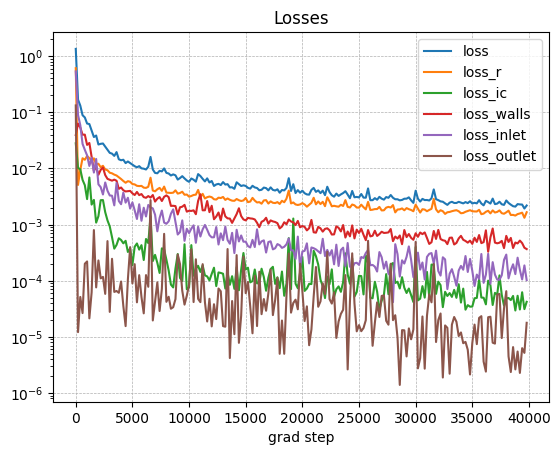

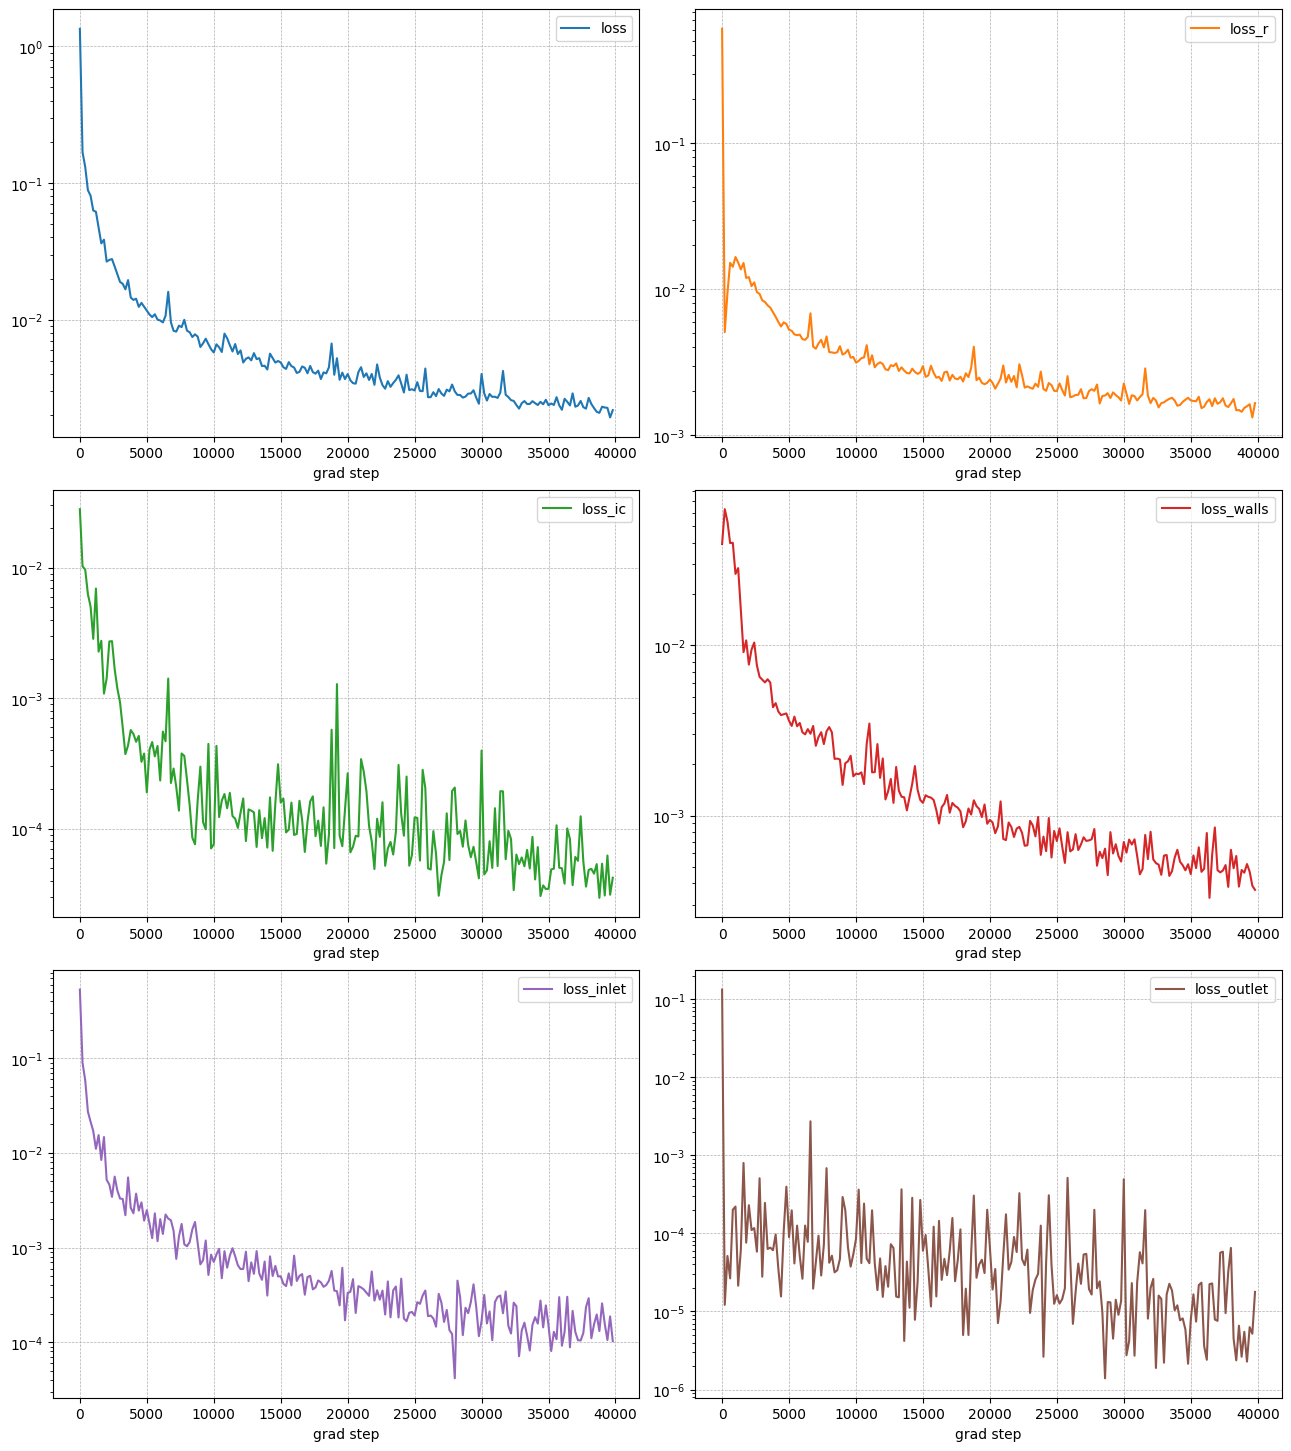

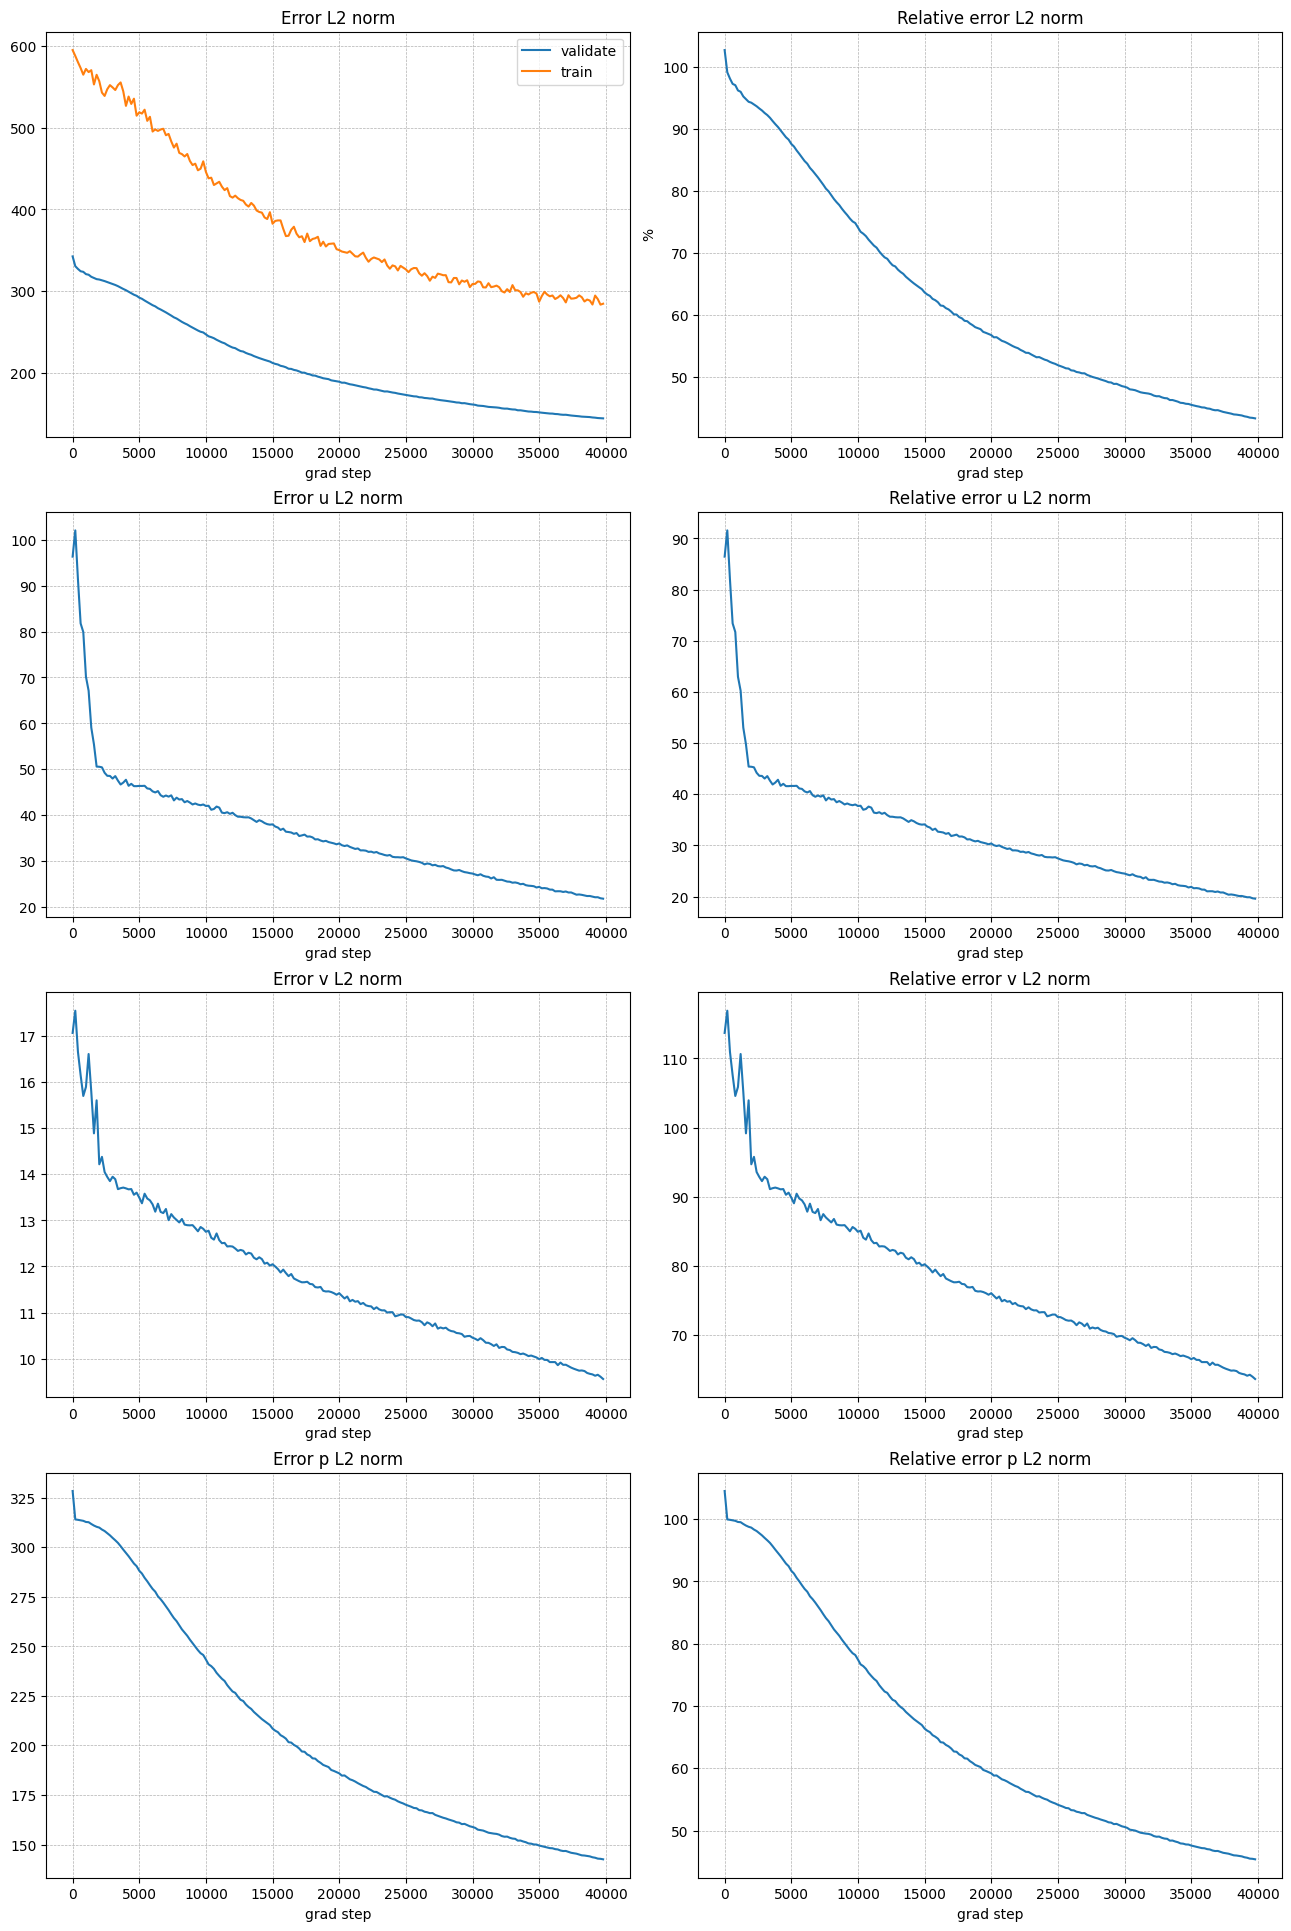

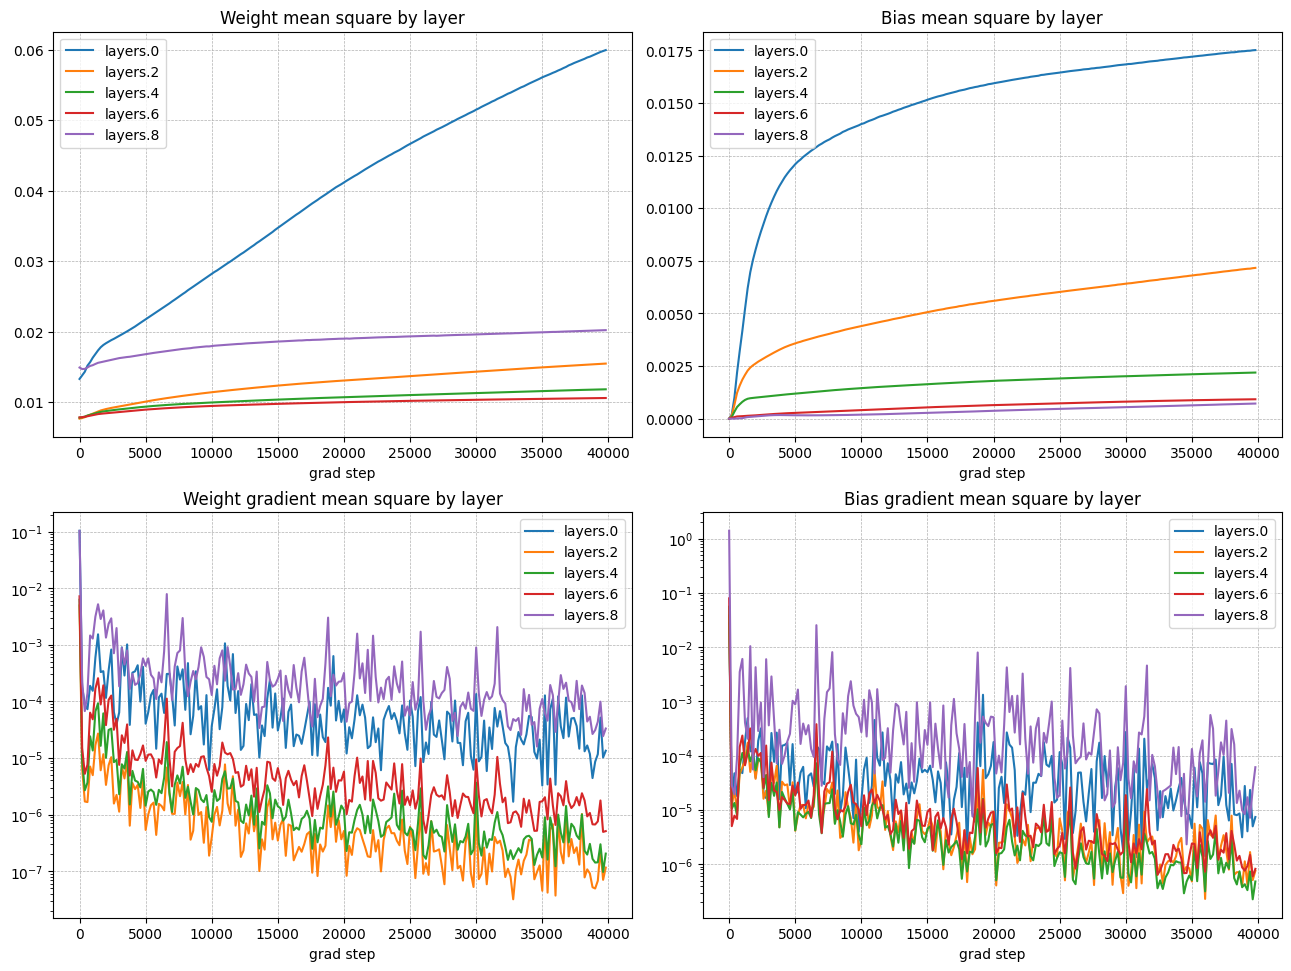

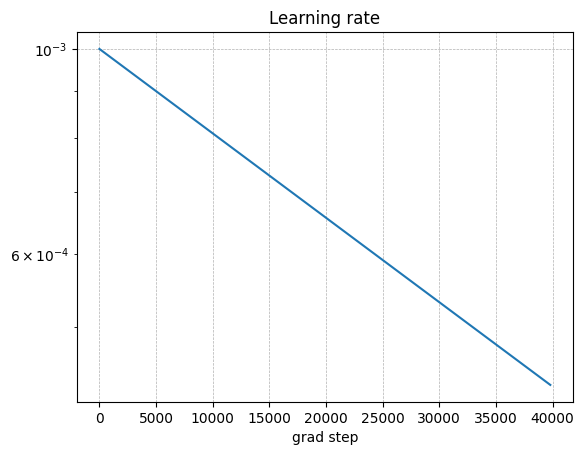

In [3]:
config_baseline = PINNConfig(
# Problem parameters
    xlims = [-0.4, 0.94],    # x_min, x_max
    ylims = [-0.1, 0.4],    # y_min, y_max
    tlims = [0.0, 1.0],    # t_min, t_max
    nu = 0.00103,    # кинематическая вязкость (масло касторовое), м2/с
    rho = 960,    # плотность (масло касторовое), кг/м3
    u0 = 1.0,    # начальная скорость в центре потока, м/с

    # Model parameters
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    init_scheme = "glorot_normal",
    layers = [3, 128, 128, 128, 128, 5],   # (x, y) -> (psi, p, sigma_xx, sigma_xy(=sigma_yx), sigma_yy)

    # Training parameters
    results_folder = PINNConfig.results_folder / "baseline",
    n_epochs = 4000,
    n_r = 70000,
    n_batches = 10,   # number of batches per epoch
    lambda_r = 1.0,
    lambda_ic = 1.0,
    lambda_walls = 1.0,
    lambda_inlet = 1.0,
    lambda_outlet = 1.0,
    lr = 1e-3,    # initial learning rate
    use_static_training_set = False,
    logging_freq = 200,    # log metrics once every N gradient descent steps

    # Log metrics (like loss and error) during training for different t intervals
    use_temporal_logging = False,
    temporal_logging_freq = 500,    # log metrics once every N gradient descent steps
    temporal_logging_nbins = 10,    # Slice time into this number of equal segments

    # Checkpointing
    use_checkpointing = True,
    checkpointing_freq = 2000,    # save model and metrics to the results_folder once every N gradient descent steps

    # Fourier Feature embedding
    use_FFE = False,
    #FFE_m = 100,
    #FFE_sigma = 1.0,
    #FFE_keep_dims = None,    # Indices of input dimensions to be passed through unchanged

    # Grad norm weighting
    use_grad_norm_weighting = False,
    #grad_norm_weighting_alpha = 0.9,
    #grad_norm_weighting_freq = 250,    # update lambdas once every N gradient descent steps

    # Causal weighting
    use_causal_weighting_scheme = False,
    #causal_m = 10,
    #causal_eps = 10,
    #W_logging_freq = 500,    # log temporal weights and L_t once every N gradient descent steps

    # Video parameters
    render_video = False,
    video_fps = 30,
    video_dpi = 100,
    video_render_freq = 100    # render a frame once every N gradient descent steps
)
scheduler_gamma = 0.9 ** (1.0 / 5000.0)
model_baseline = MultilayerPerceptronWithFFE(
   config_baseline.layers, config_baseline.init_scheme,
   use_FFE=config_baseline.use_FFE, FFE_m=config_baseline.FFE_m, 
   FFE_sigma=config_baseline.FFE_sigma, FFE_keep_dims=config_baseline.FFE_keep_dims)
optimizer = torch.optim.Adam(model_baseline.parameters(), lr=config_baseline.lr)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=scheduler_gamma)
trainer_baseline = Trainer(model_baseline, optimizer, scheduler, cfg=config_baseline)
print(config_baseline)
metrics_baseline = trainer_baseline.train()

trainer_baseline.render_metrics_plots(metrics_baseline, save_to_disk=True)
#trainer_baseline.render_model_vs_reference_video()
#trainer_baseline.render_model_vs_reference_video(video_length=0.2)

Запуск обучения с полным FFE

In [4]:
# config = replace(
#     config_baseline, 
#     results_folder=PINNConfig.results_folder / "FFE_full",
    
#     use_FFE=True,
#     FFE_m=10,
#     FFE_sigma=1.0,
#     FFE_keep_dims=None)
# model_ffe_full = MultilayerPerceptronWithFFE(
#     config.layers, config.init_scheme,
#     use_FFE=config.use_FFE, FFE_m=config.FFE_m, FFE_sigma=config.FFE_sigma, FFE_keep_dims=config.FFE_keep_dims)
# optimizer = torch.optim.Adam(model_ffe_full.parameters(), lr=config.lr)
# scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=1)
# trainer_ffe_full = Trainer(model_ffe_full, optimizer, scheduler, cfg=config)
# metrics_ffe_full = trainer_ffe_full.train()

# trainer_ffe_full.render_metrics_plots(metrics_ffe_full, save_to_disk=True)

Запуск обучения с частичным FFE для оси Y

In [5]:
# config = replace(
#     config_baseline, results_folder=PINNConfig.results_folder / "FFE_partial",
#     use_FFE=True,
#     FFE_m=10,
#     FFE_sigma=1.0,
#     FFE_keep_dims=[1])
# model_ffe_partial = MultilayerPerceptronWithFFE(
#     config.layers, config.init_scheme,
#     use_FFE=config.use_FFE, FFE_m=config.FFE_m, FFE_sigma=config.FFE_sigma, FFE_keep_dims=config.FFE_keep_dims)
# optimizer = torch.optim.Adam(model_ffe_partial.parameters(), lr=config.lr)
# scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=1)
# trainer_ffe_partial = Trainer(model_ffe_partial, optimizer, scheduler, cfg=config)
# metrics_ffe_partial = trainer_ffe_partial.train()

# trainer_ffe_partial.render_metrics_plots(metrics_ffe_partial, save_to_disk=True)

Запуск обучения с балансировкой членов loss-функции

In [6]:
# config = replace(
#     config_baseline, 
#     results_folder=PINNConfig.results_folder / "loss_balancing",
    
#     use_grad_norm_weighting=True,
#     grad_norm_weighting_alpha=0.9,
#     grad_norm_weighting_freq=250)
# model_balancing = MultilayerPerceptronWithFFE(
#     config.layers, config.init_scheme,
#     use_FFE=config.use_FFE, FFE_m=config.FFE_m, FFE_sigma=config.FFE_sigma, FFE_keep_dims=config.FFE_keep_dims)
# optimizer = torch.optim.Adam(model_balancing.parameters(), lr=config.lr)
# scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=1)
# trainer_balancing = Trainer(model_balancing, optimizer, scheduler, cfg=config)
# metrics_balancing = trainer_balancing.train()

# trainer_balancing.render_metrics_plots(metrics_balancing, save_to_disk=True)

Запуск обучения с алгоритмом causal

In [7]:
# config = replace(
#     config_baseline, 
#     results_folder=PINNConfig.results_folder / "causal",
    
#     use_causal_weighting_scheme=True,
#     causal_m=10,
#     causal_eps=10.0,
#     W_logging_freq=500
#     )
# model_causal = MultilayerPerceptronWithFFE(
#     config.layers, config.init_scheme,
#     use_FFE=config.use_FFE, FFE_m=config.FFE_m, FFE_sigma=config.FFE_sigma, FFE_keep_dims=config.FFE_keep_dims)
# optimizer = torch.optim.Adam(model_causal.parameters(), lr=config.lr)
# scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=1)
# trainer_causal = Trainer(model_causal, optimizer, scheduler, cfg=config)
# metrics_causal = trainer_causal.train()

# trainer_causal.render_metrics_plots(metrics_causal, save_to_disk=True)

Сравнение

In [8]:
# fig, ax = plt.subplots()
# ax.semilogy(metrics_baseline['step'], metrics_baseline['rel_err_l2'], label='baseline')
# ax.semilogy(metrics_ffe_full['step'], metrics_ffe_full['rel_err_l2'], label='ffe_full')
# ax.semilogy(metrics_ffe_partial['step'], metrics_ffe_partial['rel_err_l2'], label='ffe_partial')
# ax.semilogy(metrics_balancing['step'], metrics_balancing['rel_err_l2'], label='balancing')
# #ax.semilogy(metrics_causal['step'], metrics_causal['rel_err_l2'], label='causal')
# ax.set(title="Relative error L2-norm", xlabel="grad step", ylabel="%")
# ax.legend()
# plt.show()
# fig.savefig(PINNConfig.results_folder / "total_rel_err_l2_norm.png", dpi=300)